<a href="https://colab.research.google.com/github/sats505/Celebal_DS_assignments/blob/main/Week3_Shatakshi_Upadhyay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================
# END-TO-END CUSTOMER (COUNTRY) INTELLIGENCE SYSTEM
# Clustering: K-Means, DBSCAN, Hierarchical
# Classification: Random Forest, XGBoost
# Dataset: Country Data (HELP International)
# ============================================


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('Country-data.csv')

print(f"\nDataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nDataset info:")
print(df.info())

print(f"\nStatistical summary:")
print(df.describe())

print(f"\nMissing values:\n{df.isnull().sum()}")


Dataset shape: (167, 10)

First 5 rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mo

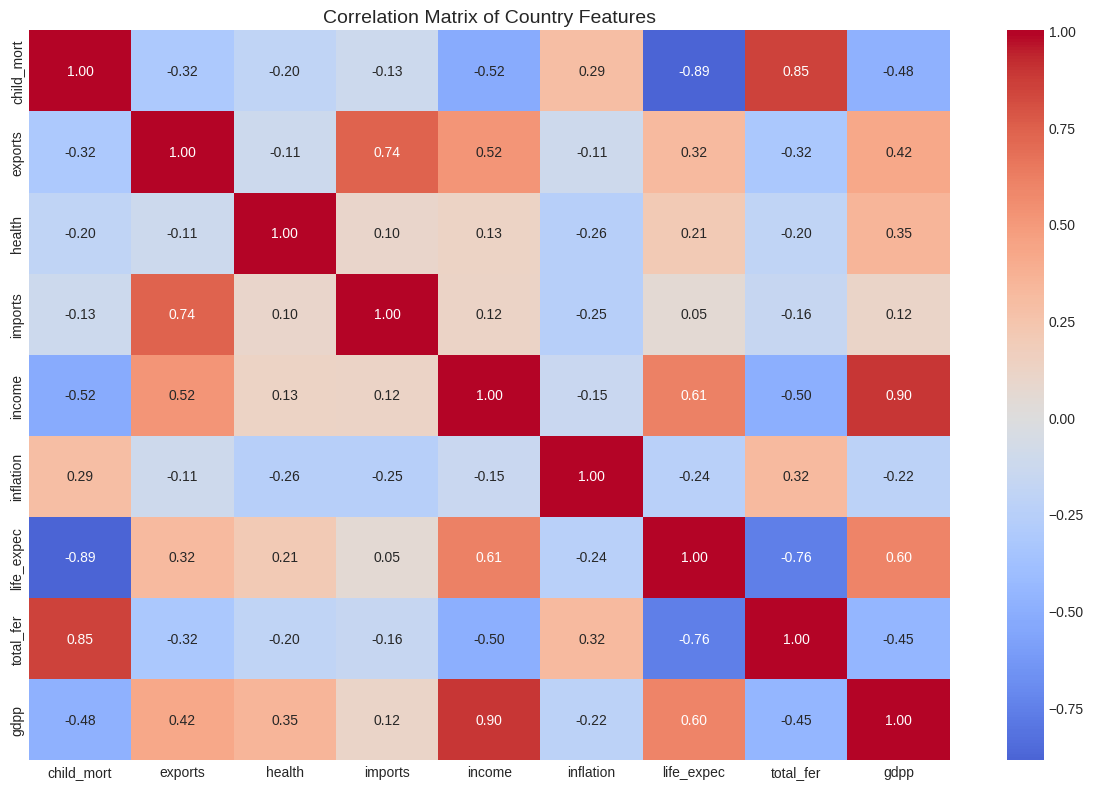

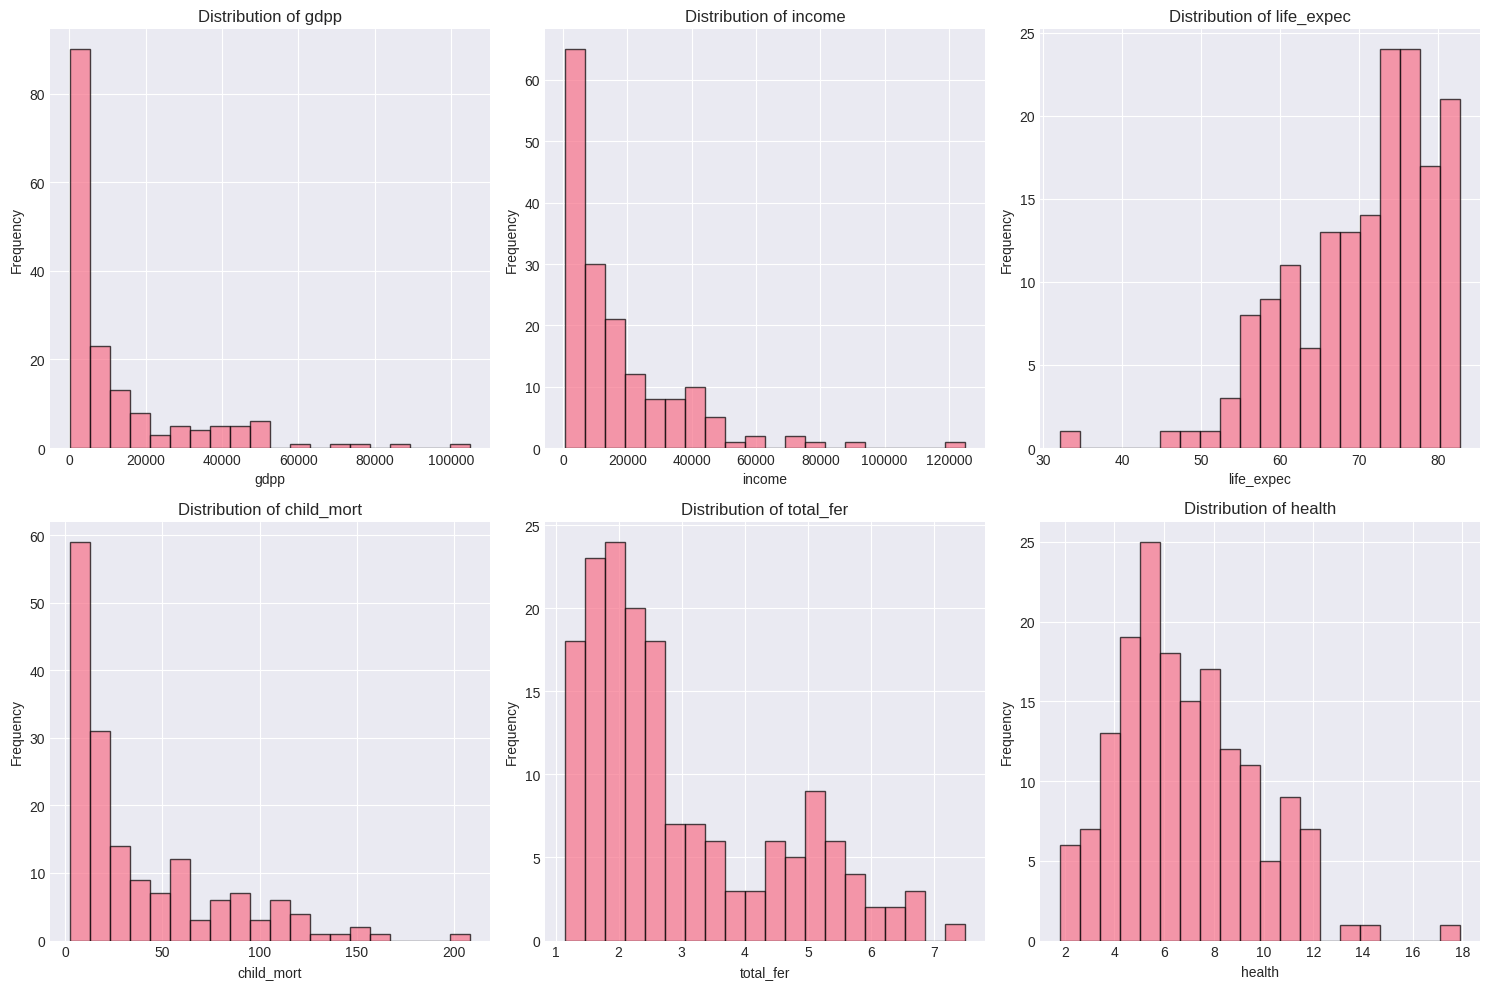

In [5]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.drop('country', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Country Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['gdpp', 'income', 'life_expec', 'child_mort', 'total_fer', 'health']
for idx, feature in enumerate(features_to_plot):
    row, col = idx // 3, idx % 3
    axes[row, col].hist(df[feature], bins=20, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()

In [6]:
feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
                'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"Features scaled using StandardScaler")
print(f"Scaled data shape: {X_scaled_df.shape}")


Features scaled using StandardScaler
Scaled data shape: (167, 9)


STEP 4: K-MEANS CLUSTERING



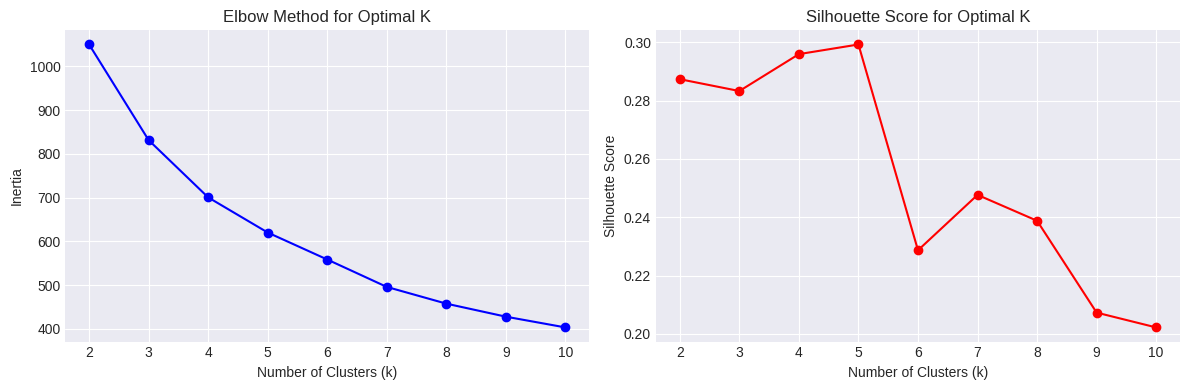


Optimal number of clusters based on silhouette score: 5

K-Means Performance:
Silhouette Score: 0.2993
Davies-Bouldin Score: 0.8718
Calinski-Harabasz Score: 57.6540


In [7]:
print("STEP 4: K-MEANS CLUSTERING" + "\n")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.grid(True)
plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=100)
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"\nOptimal number of clusters based on silhouette score: {optimal_k}")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, df['KMeans_Cluster'])
kmeans_db = davies_bouldin_score(X_scaled, df['KMeans_Cluster'])
kmeans_ch = calinski_harabasz_score(X_scaled, df['KMeans_Cluster'])

print(f"\nK-Means Performance:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score: {kmeans_db:.4f}")
print(f"Calinski-Harabasz Score: {kmeans_ch:.4f}")

In [8]:
print("STEP 5: DBSCAN CLUSTERING" + "\n")

eps_values = [0.3, 0.5, 0.7, 1.0, 1.2, 1.5]
best_dbscan_score = -1
best_eps = None
best_min_samples = None

for eps in eps_values:
    for min_samples in [3, 4, 5]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters >= 2:
            try:
                score = silhouette_score(X_scaled, labels)
                print(f"eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")
                if score > best_dbscan_score:
                    best_dbscan_score = score
                    best_eps = eps
                    best_min_samples = min_samples
            except:
                pass


dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)
n_noise_dbscan = list(df['DBSCAN_Cluster']).count(-1)

print(f"\nBest DBSCAN parameters: eps={best_eps}, min_samples={best_min_samples}")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Silhouette Score: {best_dbscan_score:.4f}")

STEP 5: DBSCAN CLUSTERING

eps=0.7, min_samples=3: clusters=8, noise=137, silhouette=-0.3241
eps=0.7, min_samples=4: clusters=2, noise=157, silhouette=-0.2275
eps=1.0, min_samples=3: clusters=6, noise=72, silhouette=0.0117
eps=1.0, min_samples=4: clusters=4, noise=84, silhouette=-0.0319
eps=1.0, min_samples=5: clusters=3, noise=94, silhouette=-0.0248
eps=1.2, min_samples=3: clusters=4, noise=41, silhouette=0.1268
eps=1.2, min_samples=4: clusters=3, noise=50, silhouette=0.1488
eps=1.2, min_samples=5: clusters=3, noise=53, silhouette=0.1484
eps=1.5, min_samples=3: clusters=2, noise=25, silhouette=0.1540

Best DBSCAN parameters: eps=1.5, min_samples=3
Number of clusters: 3
Number of noise points: 25
Silhouette Score: 0.1540


STEP 7: PCA VISUALIZATION

Explained variance ratio: [0.4595174  0.17181626]
Total variance explained: 63.13%


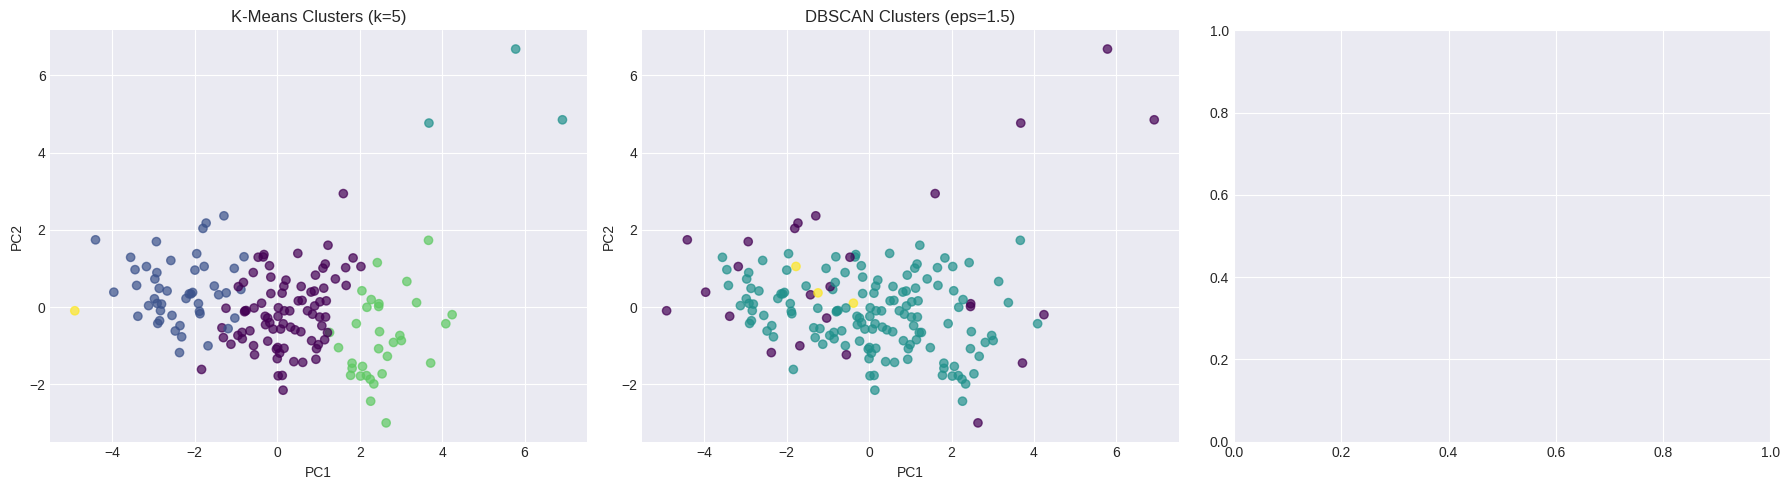

In [9]:
print("STEP 7: PCA VISUALIZATION" + "\n")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['PCA1'], df['PCA2'], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.7)
axes[0].set_title(f'K-Means Clusters (k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(df['PCA1'], df['PCA2'], c=df['DBSCAN_Cluster'], cmap='viridis', alpha=0.7)
axes[1].set_title(f'DBSCAN Clusters (eps={best_eps})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('cluster_visualizations.png', dpi=100)
plt.show()

In [10]:
print("STEP 8: CREATE CLASSIFICATION TARGET" + "\n")

# Method 1: K-Means clusters as target
# First, interpret the clusters based on GDP and child mortality
cluster_means = df.groupby('KMeans_Cluster')[['gdpp', 'child_mort', 'life_expec']].mean()
print("\nCluster characteristics:")
print(cluster_means)

# meaningful labels based on cluster means
cluster_ranking = cluster_means['gdpp'].rank().sort_values().index.tolist()
cluster_labels = {}
for rank, cluster in enumerate(cluster_ranking):
    if rank == 0:
        cluster_labels[cluster] = 'Least_Developed'
    elif rank == len(cluster_ranking) - 1:
        cluster_labels[cluster] = 'Most_Developed'
    else:
        cluster_labels[cluster] = 'Developing'

df['Development_Status'] = df['KMeans_Cluster'].map(cluster_labels)

# Method 2: binary target based on GDP median (alternative)
gdp_median = df['gdpp'].median()
df['Is_Developed'] = (df['gdpp'] > gdp_median).astype(int)

print(f"\nTarget distribution (Development Status):")
print(df['Development_Status'].value_counts())
print(f"\nGDP Median: {gdp_median:.2f}")
print(f"Binary target distribution: {df['Is_Developed'].value_counts().to_dict()}")


STEP 8: CREATE CLASSIFICATION TARGET


Cluster characteristics:
                        gdpp  child_mort  life_expec
KMeans_Cluster                                      
0                6581.809524   21.614286   73.004762
1                1900.255319   90.793617   59.212766
2               57566.666667    4.133333   81.433333
3               42118.750000    5.181250   80.081250
4                2330.000000  130.000000   60.500000

Target distribution (Development Status):
Development_Status
Developing         117
Least_Developed     47
Most_Developed       3
Name: count, dtype: int64

GDP Median: 4660.00
Binary target distribution: {0: 84, 1: 83}


In [11]:
print("STEP 9: CLASSIFICATION WITH ENSEMBLE LEARNING")
print("="*60)

# Prepare data for classification
X_class = df[feature_cols].copy()
y_class = df['Is_Developed']  # Using binary target for clearer evaluation

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution in training: {y_train.value_counts().to_dict()}")

# ========== RANDOM FOREST ==========
print("\n" + "-"*40)
print("Random Forest Classifier")
print("-"*40)

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_base, rf_params, cv=5, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f"Best parameters: {rf_grid.best_params_}")

# Predictions
rf_pred = best_rf.predict(X_test)
rf_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"\nRandom Forest Performance on Test Set:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Developing', 'Developed']))

# Cross-validation score
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1 scores: {rf_cv_scores}")
print(f"Mean CV F1: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

# ========== XGBOOST ==========
print("\n" + "-"*40)
print("XGBoost Classifier")
print("-"*40)

# Hyperparameter tuning for XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=5, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print(f"Best parameters: {xgb_grid.best_params_}")

# Predictions
xgb_pred = best_xgb.predict(X_test)
xgb_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print(f"\nXGBoost Performance on Test Set:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Developing', 'Developed']))

# Cross-validation score
xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='f1')
print(f"\nCross-validation F1 scores: {xgb_cv_scores}")
print(f"Mean CV F1: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std() * 2:.4f})")

STEP 9: CLASSIFICATION WITH ENSEMBLE LEARNING
Training set size: 133
Test set size: 34
Class distribution in training: {0: 67, 1: 66}

----------------------------------------
Random Forest Classifier
----------------------------------------
Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Performance on Test Set:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Developing       1.00      1.00      1.00        17
   Developed       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


Cross-validation F1 scores: [1.   1.   1.   0.96 0.96]
Mean CV F1: 0.9840 (+/- 0.0392)

----------------------------------------
XGBoost Classifier
----------------------------------------
Best pa

STEP 10: MODEL COMPARISON

Model Performance Comparison:
        Model  Accuracy  Precision  Recall  F1-Score
Random Forest       1.0        1.0     1.0       1.0
      XGBoost       1.0        1.0     1.0       1.0


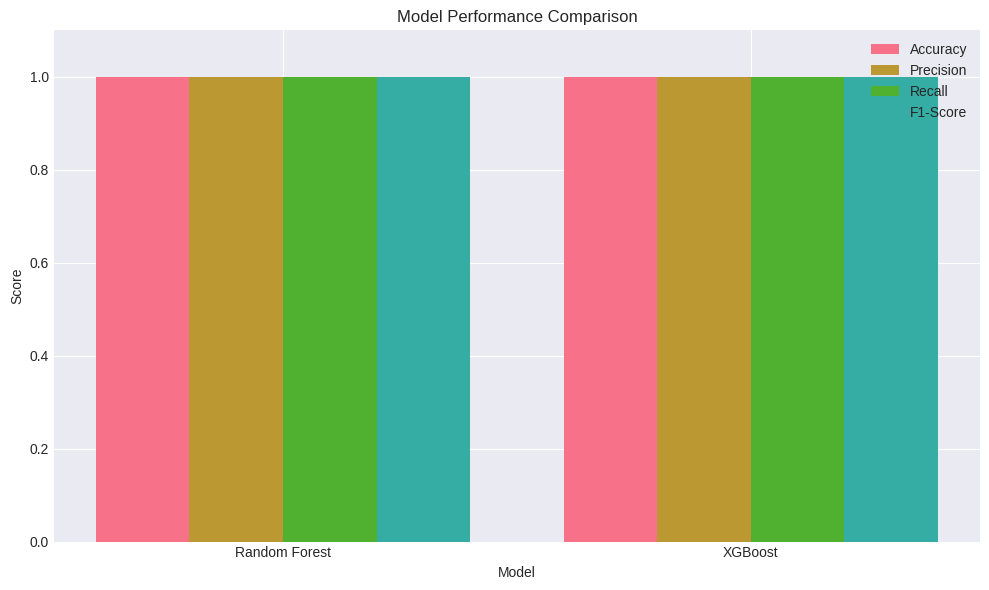

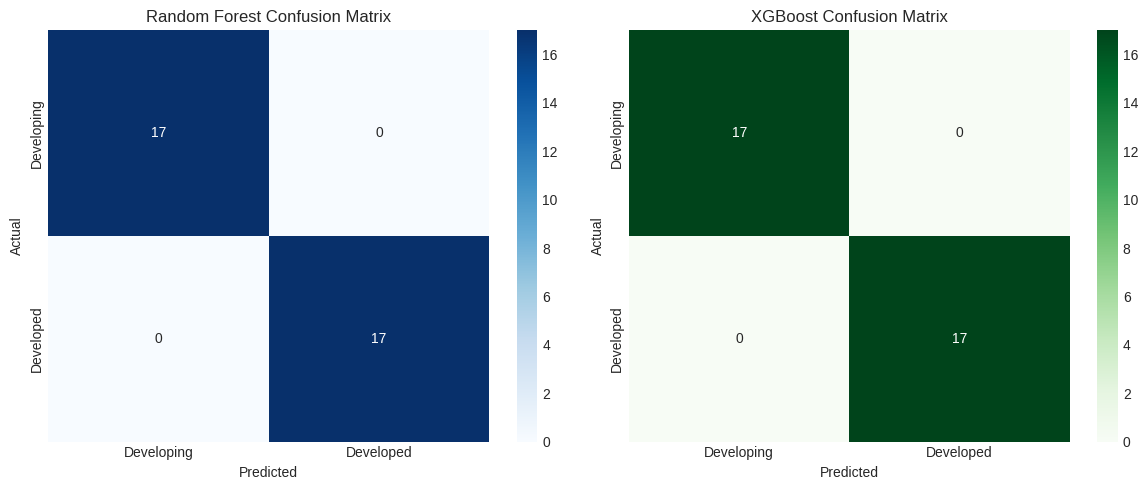

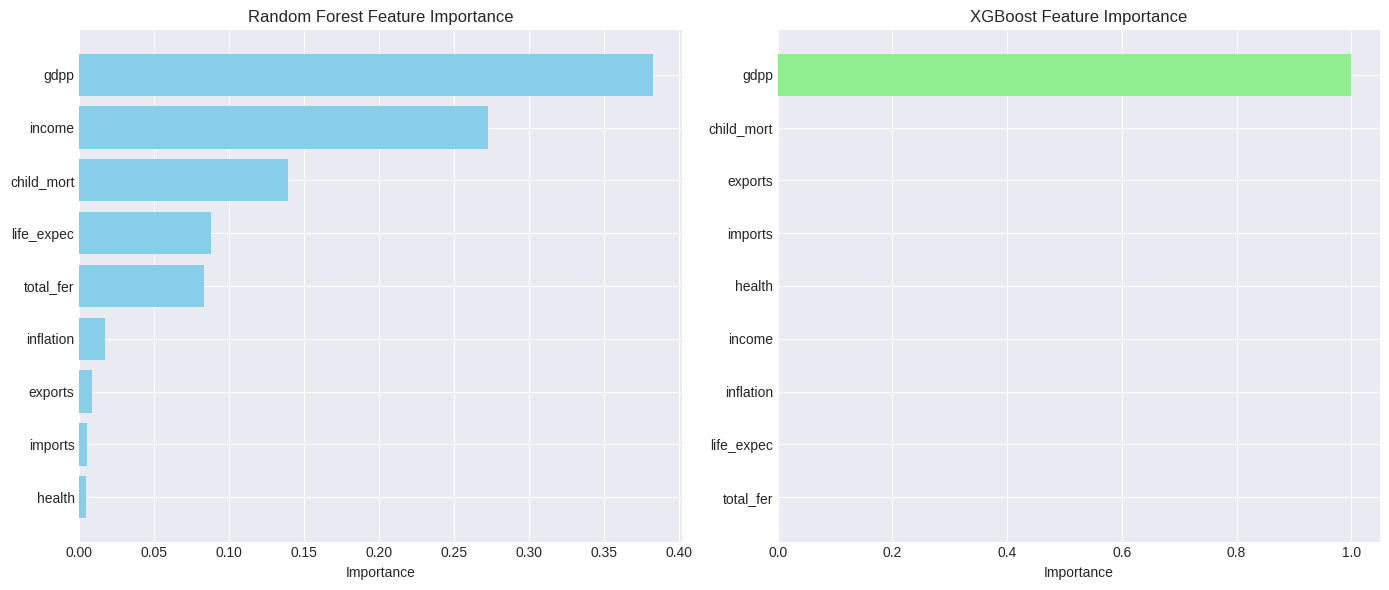

In [12]:
print("STEP 10: MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Precision': [rf_precision, xgb_precision],
    'Recall': [rf_recall, xgb_recall],
    'F1-Score': [rf_f1, xgb_f1]
})

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

# Confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_xticklabels(['Developing', 'Developed'])
ax1.set_yticklabels(['Developing', 'Developed'])

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('XGBoost Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_xticklabels(['Developing', 'Developed'])
ax2.set_yticklabels(['Developing', 'Developed'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

# Feature importance
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.barh(rf_importance['feature'], rf_importance['importance'], color='skyblue')
ax1.set_title('Random Forest Feature Importance')
ax1.set_xlabel('Importance')
ax1.invert_yaxis()

ax2.barh(xgb_importance['feature'], xgb_importance['importance'], color='lightgreen')
ax2.set_title('XGBoost Feature Importance')
ax2.set_xlabel('Importance')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

In [14]:
print("STEP 11: BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*60)

# Identify countries that need aid most
df['Need_Aid'] = df['KMeans_Cluster'].isin([cluster_ranking[0]]).astype(int) | (df['DBSCAN_Cluster'] == -1).astype(int)

high_need_countries = df[df['Need_Aid'] == 1][['country', 'gdpp', 'child_mort', 'life_expec', 'KMeans_Cluster', 'DBSCAN_Cluster']]
high_need_countries = high_need_countries.sort_values('child_mort', ascending=False)

print("\nHIGHEST PRIORITY COUNTRIES FOR AID ($10M ALLOCATION):")
print("="*60)
print(high_need_countries.to_string(index=False))

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print(f"""
1. CLUSTERING RESULTS:
   - K-Means identified {optimal_k} distinct country segments
   - DBSCAN found {n_clusters_dbscan} clusters with {n_noise_dbscan} outlier countries
   - Best clustering method (based on silhouette score): {'K-Means' if kmeans_silhouette > best_dbscan_score else 'DBSCAN'}

2. CLASSIFICATION PERFORMANCE:
   - Random Forest F1-Score: {rf_f1:.4f}
   - XGBoost F1-Score: {xgb_f1:.4f}
   - Best performing model: {'XGBoost' if xgb_f1 > rf_f1 else 'Random Forest'}

3. MOST IMPORTANT FEATURES FOR DEVELOPMENT PREDICTION:
   - Top 3 features: {rf_importance['feature'].head(3).tolist()}

4. AID ALLOCATION RECOMMENDATIONS:
   - Priority 1 (Immediate aid): {len(high_need_countries[high_need_countries['DBSCAN_Cluster'] == -1])} outlier countries
   - Priority 2 (High need): Countries in Least Developed cluster
   - Estimated budget allocation: Focus $7M on Priority 1 countries, $3M on Priority 2

5. STRATEGIC ACTIONS:
   - Invest in healthcare to reduce child mortality (highest correlation with development)
   - Improve economic infrastructure to boost GDP per capita
   - Target education programs in high-fertility, low-life-expectancy countries
""")

# Save results to CSV
df[['country', 'KMeans_Cluster', 'DBSCAN_Cluster',
    'Development_Status', 'Is_Developed', 'Need_Aid'] + feature_cols].to_csv('country_clustering_results.csv', index=False)
print("\nResults saved to 'country_clustering_results.csv'")

# Summary of what each cluster means
print("\n" + "="*60)
print("CLUSTER INTERPRETATION (Based on K-Means):")
print("="*60)
for cluster in sorted(df['KMeans_Cluster'].unique()):
    cluster_data = df[df['KMeans_Cluster'] == cluster]
    print(f"\nCluster {cluster}: {cluster_labels[cluster]}")
    print(f"  Number of countries: {len(cluster_data)}")
    print(f"  Avg GDP per capita: ${cluster_data['gdpp'].mean():.2f}")
    print(f"  Avg Child Mortality: {cluster_data['child_mort'].mean():.1f}")
    print(f"  Avg Life Expectancy: {cluster_data['life_expec'].mean():.1f} years")
    print(f"  Example countries: {', '.join(cluster_data['country'].head(3).tolist())}")

STEP 11: BUSINESS INSIGHTS & RECOMMENDATIONS

HIGHEST PRIORITY COUNTRIES FOR AID ($10M ALLOCATION):
                 country   gdpp  child_mort  life_expec  KMeans_Cluster  DBSCAN_Cluster
                   Haiti    662       208.0        32.1               1              -1
            Sierra Leone    399       160.0        55.0               1              -1
                    Chad    897       150.0        56.5               1               0
Central African Republic    446       149.0        47.5               1              -1
                    Mali    708       137.0        59.5               1               0
                 Nigeria   2330       130.0        60.5               4              -1
                   Niger    348       123.0        58.8               1               0
                  Angola   3530       119.0        60.1               1              -1
        Congo, Dem. Rep.    334       116.0        57.5               1              -1
            Burkina 